# Figure 3. Comparison of standard TRK and SD-TRK (ill-conditioned)

Reproduces Figure 3 (§5.1.4) of *A Spectrally Damped Tensor Randomized
Kaczmarz Method for Doubly Noisy Tensor Systems*.

- **(a) Experiment 5.1.4** — ill-conditioned standard TRK (`Fig3a.eps`)
- **(b) Experiment 5.1.4** — ill-conditioned SD-TRK (`Fig3b.eps`)

**Common setting.** Dimensions $(n_1,n_2,n_3,n_4)=(20,10,5,5)$. To construct an
ill-conditioned regime, a Gaussian tensor is generated and its $j$-th lateral slice is multiplied
by a scale factor $c_j$, where $c_1,\ldots,c_{n_2}$ decay geometrically from $1$ to $2\times 10^{-2}$ —
this makes the smallest singular values of the Fourier-domain frontal slices $\hat{\tilde{A}}^{(k)}$
small. The ground truth $\mathcal{X}^\star$ is the zero tensor except that its first four first-mode
slices are filled with i.i.d. standard Gaussian entries scaled by $0.75$. The noise configuration is
$\delta_A=0.01$ (minor operator perturbation) and $\delta_B=0.5$ (substantial observation noise),
isolating the instability caused by inversion of near-singular spectral components. Both algorithms
start from $\mathcal{X}^0=\mathbf{0}$ and run $T=2000$ iterations; curves are averaged over $20$
Monte Carlo trials. Each panel compares the true reconstruction error
$\|\mathcal{X}^t-\mathcal{X}^\star\|_F$ with the observable residual
$\|\tilde{\mathcal{A}}\mathcal{X}^t-\tilde{\mathcal{B}}\|_F$.

**SD-TRK** adopts a stronger damping configuration, $\omega=0.7$, with the slice-dependent rule

$$\lambda^{(k)}=\lambda_{\mathrm{floor}}+\lambda_{\mathrm{scale}}\,(\delta_A^2+\delta_B^2)\,\frac{\|\hat{\tilde{A}}^{(k)}\|_F^2}{n_1},\qquad k=1,\ldots,n_3,\qquad \lambda_{\mathrm{scale}}=100.0,\ \lambda_{\mathrm{floor}}=10^{-6}.$$

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'font.size': 14,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'ps.fonttype': 42,
})

In [17]:
def t_prod(A, B):
    # t-product: FFT along mode 3 -> slice-wise matmul -> inverse FFT (Appendix A)
    n1, _, n3 = A.shape
    n4 = B.shape[1]
    A_hat = np.fft.fft(A, axis=2)
    B_hat = np.fft.fft(B, axis=2)
    C_hat = np.zeros((n1, n4, n3), dtype=complex)
    for k in range(n3):
        C_hat[:, :, k] = A_hat[:, :, k] @ B_hat[:, :, k]
    return np.fft.ifft(C_hat, axis=2).real


def t_transpose(A):
    # conjugate transpose: transpose each frontal slice, then reverse slices 2..n3
    n1, n2, n3 = A.shape
    At = np.zeros((n2, n1, n3), dtype=A.dtype)
    At[:, :, 0] = A[:, :, 0].T
    for k in range(1, n3):
        At[:, :, k] = A[:, :, n3 - k].T
    return At


def t_inv(tube):
    # tube inverse: reciprocal per Fourier frequency (nonzero by Assumption 2.9)
    hat = np.fft.fft(tube, axis=2)
    return np.fft.ifft(1.0 / hat, axis=2).real


def tnorm(T):
    # Frobenius norm of a tensor
    return np.linalg.norm(T.reshape(-1))


def trk_step(X, Aslice, Bslice):
    # standard TRK update: X <- X + A_i^* (A_i A_i^*)^{-1} (B_i - A_i X)
    resid = Bslice - t_prod(Aslice, X)
    At = t_transpose(Aslice)
    scale = t_inv(t_prod(Aslice, At))
    return X + t_prod(At, t_prod(scale, resid))


def sdtrk_step(X, Aslice, Bslice, lambdas, omega):
    # SD-TRK update, slice-wise in the Fourier domain (Algorithm 1):
    # X^(k) <- X^(k) - omega * a^* (a a^* + lambda_k)^{-1} (a X^(k) - b)
    A_hat = np.fft.fft(Aslice, axis=2)
    B_hat = np.fft.fft(Bslice, axis=2)
    X_hat = np.fft.fft(X, axis=2)
    for k in range(X.shape[2]):
        a = A_hat[0, :, k][None, :]  # row slice -> a a^* is a scalar
        resid = a @ X_hat[:, :, k] - B_hat[0, :, k][None, :]
        denom = np.linalg.norm(a)**2 + lambdas[k]
        X_hat[:, :, k] -= omega * (a.conj().T / denom) @ resid
    return np.fft.ifft(X_hat, axis=2).real

In [18]:
n1, n2, n3, n4 = 20, 10, 5, 5
delta_A, delta_B = 1e-2, 0.5   # minor operator noise, substantial observation noise
T = 2000
trials = 20
omega = 0.7
lambda_scale, lambda_floor = 100.0, 1e-6


def make_data(rng):
    # ill-conditioned A: j-th lateral slice scaled by c_j, geometric decay 1 -> 2e-2
    cj = np.geomspace(1.0, 2e-2, n2)[None, :, None]
    Atrue = rng.standard_normal((n1, n2, n3)) * cj

    # sparse ground truth: only the first 4 first-mode slices are active (x 0.75)
    Xstar = np.zeros((n2, n4, n3))
    Xstar[:4] = 0.75 * rng.standard_normal((4, n4, n3))

    Btrue = t_prod(Atrue, Xstar)
    Aobs = Atrue + delta_A * rng.standard_normal((n1, n2, n3))
    Bobs = Btrue + delta_B * rng.standard_normal((n1, n4, n3))
    return Xstar, Aobs, Bobs


def lambda_rule(Aobs):
    # slice-dependent damping: lambda_k = floor + scale*(dA^2 + dB^2)*||A_hat^(k)||_F^2 / n1
    A_hat = np.fft.fft(Aobs, axis=2)
    slicesq = np.array([np.linalg.norm(A_hat[:, :, k])**2 for k in range(n3)])
    return lambda_floor + lambda_scale * (delta_A**2 + delta_B**2) * slicesq / n1


def run_trials(method, seed=7):
    # average true error and residual over independent Monte Carlo trials
    master = np.random.default_rng(seed)
    curves = {'true': [], 'resid': []}
    for _ in range(trials):
        rng = np.random.default_rng(int(master.integers(0, 2**32 - 1)))
        Xstar, Aobs, Bobs = make_data(rng)
        lambdas = lambda_rule(Aobs)
        rowsq = np.array([tnorm(Aobs[i:i+1])**2 for i in range(n1)])
        prob = rowsq / rowsq.sum()
        X = np.zeros((n2, n4, n3))
        htrue, hres = [], []
        for t in range(T):
            i = int(rng.choice(n1, p=prob))
            if method == 'sdtrk':
                X = sdtrk_step(X, Aobs[i:i+1], Bobs[i:i+1], lambdas, omega)
            else:
                X = trk_step(X, Aobs[i:i+1], Bobs[i:i+1])
            htrue.append(tnorm(X - Xstar))
            hres.append(tnorm(t_prod(Aobs, X) - Bobs))
        curves['true'].append(htrue)
        curves['resid'].append(hres)
    return {key: np.mean(vals, axis=0) for key, vals in curves.items()}


def moving_average(values, window=75):
    # residual curves are smoothed for readability, as in the published figure
    kernel = np.ones(window) / window
    padded = np.pad(values, (window - 1, 0), mode='edge')
    return np.convolve(padded, kernel, mode='valid')


def plot_metrics(curves, marker, mface, fname, loc='best'):
    smoothed = moving_average(curves['resid'])
    lo = 0.8 * min(curves['true'].min(), smoothed.min())
    hi = 1.2 * max(curves['true'].max(), smoothed.max())
    plt.figure(figsize=(6, 4))
    plt.semilogy(curves['true'], color='black', marker=marker, markerfacecolor=mface,
                 markevery=T // 12, markersize=2.5, linewidth=1.5
                 label=r'$\|\mathcal{X}^t - \mathcal{X}^\star\|_F$')
    plt.semilogy(smoothed, color='black', linewidth=1.5,
                 label=r'$\|\tilde{\mathcal{A}}\mathcal{X}^t - \tilde{\mathcal{B}}\|_F$')
    plt.xlabel(r'Iteration $t$')
    plt.ylim(lo, hi)
    ax = plt.gca()
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=5))
    ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10.0))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    plt.legend(frameon=False, handlelength=1.4, labelspacing=0.25, borderpad=0.2, loc=loc)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (810668340.py, line 69)

### (a) Experiment 5.1.4 — Ill-Conditioned Standard TRK

**Expected result.** The true reconstruction error initially decreases, then reverses direction and
grows toward a large asymptotic level of approximately $12.1125$ — the characteristic V-shaped
trajectory of **semi-convergence**. Without any regularization mechanism, standard TRK repeatedly
inverts severely ill-conditioned spectral components, so observation noise is strongly amplified
by the near-zero singular values.

final error to X_star = 12.1125
final residual        = 12.4192


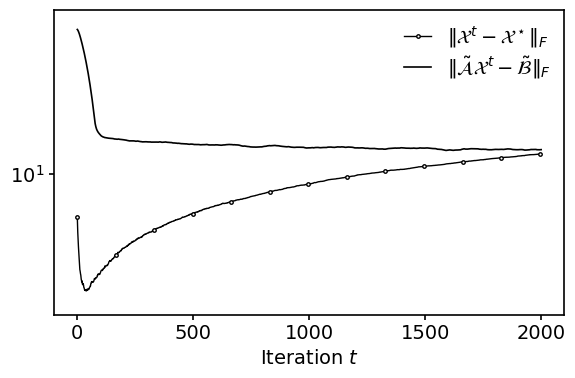

In [19]:
trk = run_trials('trk')

print(f"final error to X_star = {trk['true'][-1]:.4f}")
print(f"final residual        = {trk['resid'][-1]:.4f}")

plot_metrics(trk, marker='o', mface='white', fname='Fig3a.eps')

### (b) Experiment 5.1.4 — Ill-Conditioned SD-TRK

**Expected result.** The frequency-dependent damping parameters $\{\lambda^{(k)}\}$ act as a
spectral regularization mechanism, damping the amplification associated with near-zero singular
values. The true reconstruction error decreases nearly monotonically and stabilizes near an error
floor of approximately $2.1013$ — about $5.76$ times smaller than standard TRK.

final error to X_star = 2.1013
final residual        = 9.9009


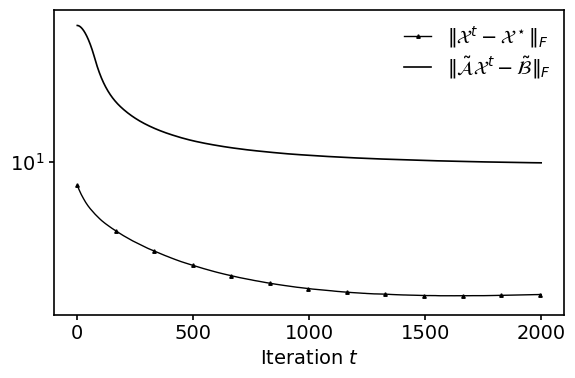

In [20]:
sdtrk = run_trials('sdtrk')

print(f"final error to X_star = {sdtrk['true'][-1]:.4f}")
print(f"final residual        = {sdtrk['resid'][-1]:.4f}")

plot_metrics(sdtrk, marker='^', mface='black', fname='Fig3b.eps', loc='upper right')